#	Exercise 1: Compute autocorrelation

**Step 1**: Generate the Chain: Reuse your Metropolis-Hastings code from the previous assignment to generate a chain of 
 samples.

**Step 2**: Compute Errors:

*	Calculate the **standard deviation** $\sigma_{y}$ and the **naive error** $ \dfrac{\sigma_{y}}{\sqrt{N}} $.

*	Calculate the **autocovariance**
$$C_y(t)  =(1-\dfrac{t}{N})\bigl( \langle y_i y_{i+t} \rangle - \langle y_i \rangle  \langle y_{i+t}\rangle\bigr) \approx (1-\dfrac{t}{N})\langle (y_i - \overline{y})( y_{i+t} - \overline{y}) \rangle $$
*	Calculate the **integrated autocorelation time** 
$$ \tau_{int} = \dfrac{1}{2} + \sum_{t=1}^{N-1} \dfrac{C_y(t)}{C_y(0)}.$$
and the **corrected error**

$$ \sigma_{\overline{y}} = \dfrac{1}{\sqrt{N}} \sigma_{y} \times \sqrt{2\tau_{int}}$$
<!-- 
where $$ \tau_{int} = \dfrac{1}{2} + \sum_{t=1}^{N-1} \dfrac{C_y(t)}{C_y(0)}.$$

$$C_y(t)  =(1-\dfrac{t}{N})\bigl( \langle y_i y_{i+t} \rangle - \langle y_i \rangle  \langle y_{i+t}\rangle\bigr) \approx (1-\dfrac{t}{N})\langle (y_i - \overline{y})( y_{i+t} - \overline{y}) \rangle $$ -->
**Step 3** Visualization: Plot the normalized autocorrelation function $\rho(t)$ against lag t
$$\rho(t) = \dfrac{C_y(t)}{C_y(0)}$$

**Questions**:
+	What does it mean if $\rho(t)$ stays high for a long time (large t)?
+	If your chain has 100000 steps and $\tau_{int} = 50$, how many "independent" data points have you actually collected?
+	How would increasing the proposal step size in your Metropolis algorithm likely change the shape of the $C_y(t)$ plot?


In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_states = 5
observable = np.arange(N_states)         

unnorm    = np.exp(-np.arange(N_states))
P_desired = unnorm / unnorm.sum()

# Acceptance matrix  A(i,j) = min(1, P(j)/P(i))
A = np.zeros((N_states, N_states))
for i in range(N_states):
    for j in range(N_states):
        A[i, j] = min(1.0, P_desired[j] / P_desired[i])

#Metropolis-Hastings chain 
n_steps = 100000
state = np.random.randint(0, N_states)
trajectory = []

for _ in range(n_steps):
    proposed  = np.random.randint(0, N_states)
    p_accept  = A[state, proposed]
    u         = np.random.uniform(0, 1)
    if u <= p_accept:
        state = proposed
    trajectory.append(state)

trajectory = np.array(trajectory)
y          = trajectory.astype(float)    # observable sequence y_i

theory_mean = np.dot(P_desired, observable)
print(f"Chain length N        = {n_steps}")
print(f"Sample mean  y_bar    = {y.mean():.4f}")
print(f"Theoretical mean  mu  = {theory_mean:.4f}")

Chain length N        = 100000
Sample mean  y_bar    = 0.5507
Theoretical mean  mu  = 0.5481


### Standard deviation and naive error

In [2]:
N         = len(y)
y_bar     = y.mean()
sigma_y   = y.std(ddof=0)           # sigma_y
naive_err = sigma_y / np.sqrt(N)    # sigma_y / sqrt(N)

print(f"sigma_y     = {sigma_y:.6f}")
print(f"Naive error = {naive_err:.6f}")

sigma_y     = 0.868718
Naive error = 0.002747


### Autocovariance

$$C_y(t) = \left(1 - \frac{t}{N}\right) \langle (y_i - \bar{y})(y_{i+t} - \bar{y}) \rangle$$

In [6]:
T_MAX = min(2000, N // 2)   # max lag to compute
yc    = y - y_bar           # centred series

C = np.array([
    (1 - t / N) * np.mean(yc[:N - t] * yc[t:])
    for t in range(T_MAX)
])

print(f"C_y(0) = {C[0]:.6f}   (should equal sigma_y^2 = {sigma_y**2:.6f})")

C_y(0) = 0.754671   (should equal sigma_y^2 = 0.754671)


### Integrated autocorrelation time and corrected error

$$\tau_{\rm int} = \frac{1}{2} + \sum_{t=1}^{N-1} \frac{C_y(t)}{C_y(0)}, \qquad
\sigma_{\bar{y}} = \frac{\sigma_y}{\sqrt{N}} \sqrt{2\tau_{\rm int}}$$

We truncate the sum once $|\rho(t)|$ drops below a noise threshold to avoid accumulating noise.

In [7]:
rho = C / C[0]   # normalised autocorrelation rho(t)

# Truncate at first lag where |rho| < 0.05
threshold   = 0.05
cutoff_idxs = np.where(np.abs(rho) < threshold)[0]
t_cut       = cutoff_idxs[0] if len(cutoff_idxs) else T_MAX

tau_int       = 0.5 + rho[1:t_cut].sum()
corrected_err = (sigma_y / np.sqrt(N)) * np.sqrt(2 * tau_int)

print(f"Truncation lag  t_cut         = {t_cut}")
print(f"tau_int                       = {tau_int:.2f}")
print(f"Naive    error  sigma_y/sqrtN = {naive_err:.6f}")
print(f"Corrected error sigma_ybar    = {corrected_err:.6f}")
print(f"Ratio  corrected / naive      = {corrected_err/naive_err:.2f}  "
      f"(= sqrt(2*tau_int) = {np.sqrt(2*tau_int):.2f})")

Truncation lag  t_cut         = 7
tau_int                       = 2.11
Naive    error  sigma_y/sqrtN = 0.002747
Corrected error sigma_ybar    = 0.005646
Ratio  corrected / naive      = 2.06  (= sqrt(2*tau_int) = 2.06)


### Visualisation


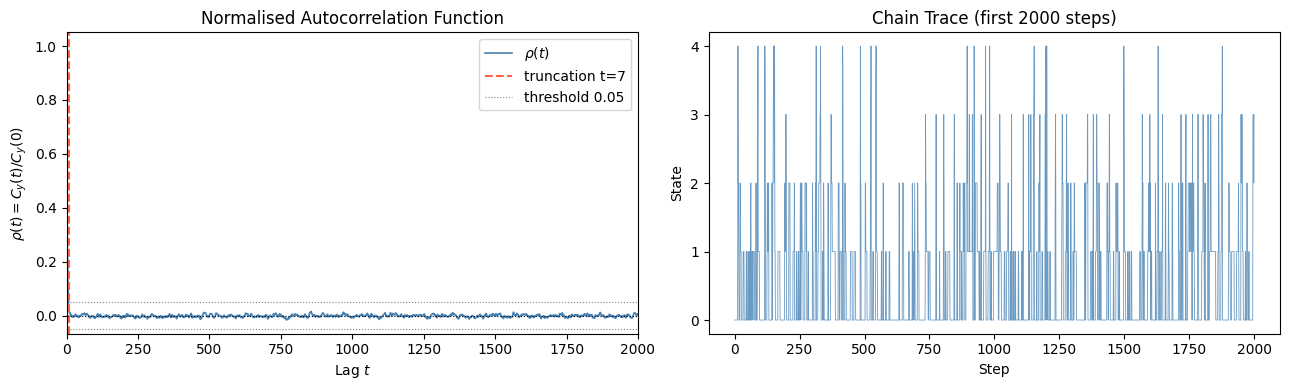

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: rho(t) vs lag
ax = axes[0]
lags = np.arange(T_MAX)
ax.plot(lags, rho, color='steelblue', lw=1.2, label=r'$\rho(t)$')
ax.axvline(t_cut, color='tomato', ls='--', label=f'truncation t={t_cut}')
ax.axhline(0,          color='k',    ls=':',  lw=0.8)
ax.axhline( threshold, color='gray', ls=':', lw=0.8, label=f'threshold {threshold}')
ax.axhline(-threshold, color='gray', ls=':', lw=0.8)
ax.set_xlabel('Lag $t$')
ax.set_ylabel(r'$\rho(t) = C_y(t)/C_y(0)$')
ax.set_title('Normalised Autocorrelation Function')
ax.legend()
ax.set_xlim(0, T_MAX)

# Right: chain trace
ax2 = axes[1]
ax2.plot(y[:2000], lw=0.6, color='steelblue', alpha=0.8)
ax2.set_xlabel('Step')
ax2.set_ylabel('State')
ax2.set_title('Chain Trace (first 2000 steps)')
ax2.set_yticks(np.arange(N_states))

plt.tight_layout()
plt.show()

## Summary


In [10]:
n_independent = N / (2 * tau_int)

print("=" * 50)
print(f"  N                       = {N:>10,}")
print(f"  y_bar (sample mean)     = {y_bar:>10.4f}")
print(f"  Theoretical mean mu     = {theory_mean:>10.4f}")
print(f"  sigma_y                 = {sigma_y:>10.6f}")
print(f"  Naive error             = {naive_err:>10.6f}")
print(f"  tau_int                 = {tau_int:>10.2f}")
print(f"  Corrected error         = {corrected_err:>10.6f}")
print(f"  N_eff = N / (2*tau_int) = {n_independent:>10.1f}")
print("=" * 50)

  N                       =    100,000
  y_bar (sample mean)     =     0.5507
  Theoretical mean mu     =     0.5481
  sigma_y                 =   0.868718
  Naive error             =   0.002747
  tau_int                 =       2.11
  Corrected error         =   0.005646
  N_eff = N / (2*tau_int) =    23677.7


## Answers to Questions

**Q1 — What does it mean if $\rho(t)$ stays high for a long time (large $t$)?**

It means consecutive samples are **strongly correlated**: the chain is mixing slowly and stays near its current state for many steps. The effective number of independent samples $N_{\rm eff} = N/(2\tau_{\rm int})$ is much smaller than $N$, so the naive error $\sigma_y/\sqrt{N}$ **underestimates** the true uncertainty.

---

**Q2 — If $N = 100\,000$ and $\tau_{\rm int} = 50$, how many independent points?**

$$N_{\rm eff} = \frac{N}{2\,\tau_{\rm int}} = \frac{100\,000}{100} = \mathbf{1\,000}$$

Only ~1 000 truly independent samples, even though the chain has 100 000 steps.

---

**Q3 — How would increasing the proposal step size change the $C_y(t)$ plot?**

In our uniform-proposal Metropolis, proposing states further away means lower acceptance probability $A(i,j) = P(j)/P(i) \ll 1$ for those moves, so the chain **rejects more often** and stays stuck in the same state for many steps. This means $\rho(t)$ decays **more slowly** and $\tau_{\rm int}$ increases — the autocorrelation plot looks flatter for longer.

The optimal acceptance rate (roughly **23–50%** for Metropolis) minimises $\tau_{\rm int}$ by balancing exploration and acceptance.